# Lab 6 – Frequency Domain Filtering
**Course:** ARTI 404 – Image Processing  
**Topic:** Frequency Domain

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

## Procedural Example – Laplacian Filter in the Frequency Domain

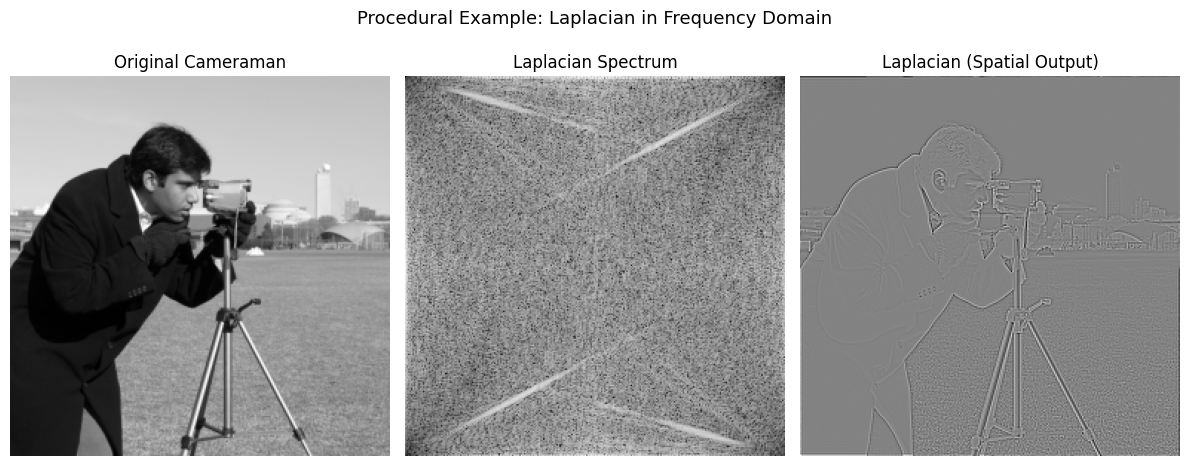

In [3]:
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))  # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = fft2(image)

# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')

plt.suptitle('Procedural Example: Laplacian in Frequency Domain', fontsize=13)
plt.tight_layout()
plt.savefig('procedural_laplacian.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Assessment Task #1 – Sobel Filters in the Frequency Domain

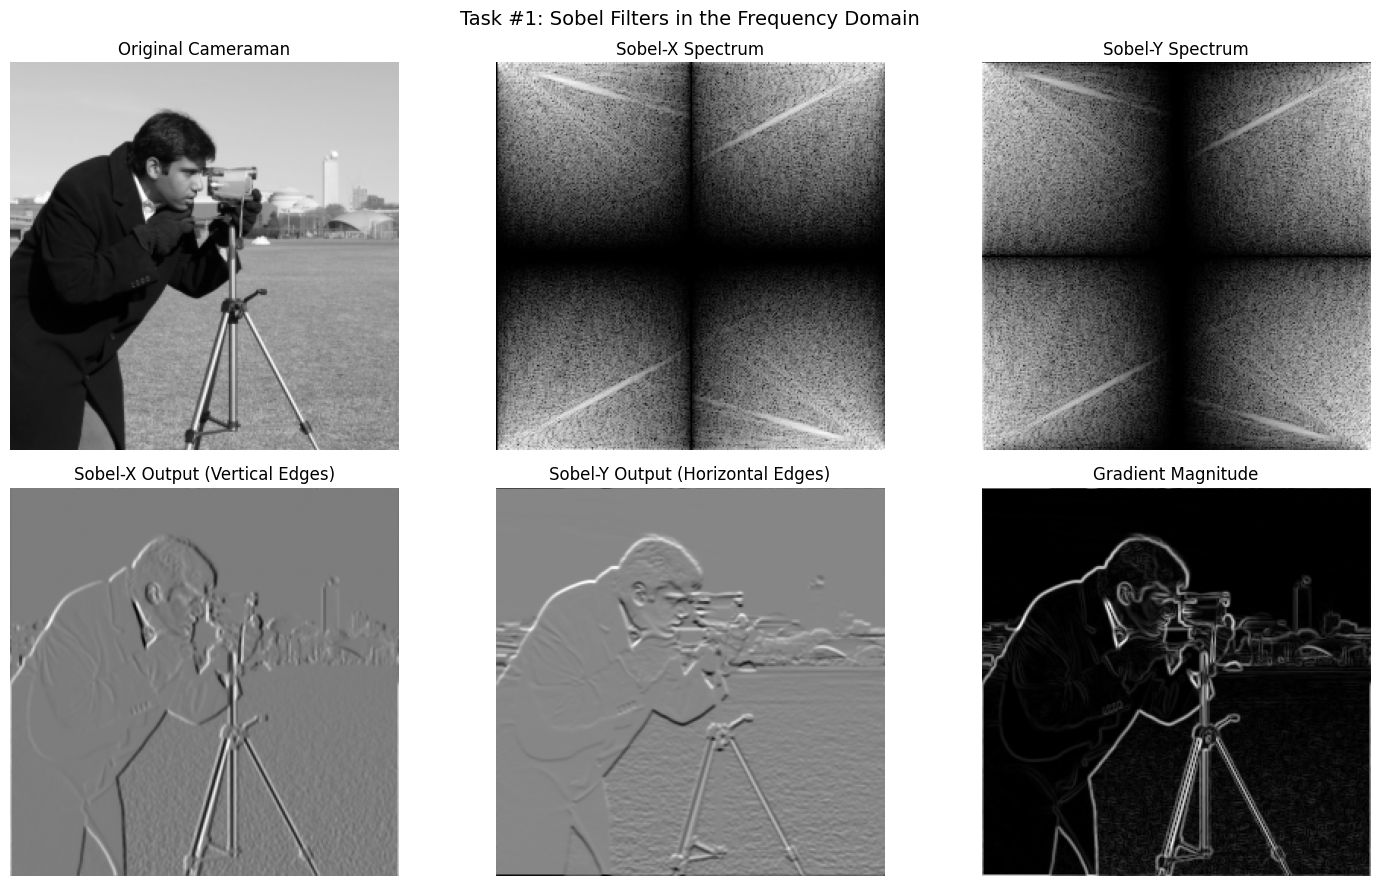

Sobel-X detects vertical edges (changes in horizontal direction).
Sobel-Y detects horizontal edges (changes in vertical direction).
Gradient Magnitude combines both for full edge detection.


In [4]:
# Load and resize image
image = data.camera()
image = resize(image, (256, 256))

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float64)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float64)

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))  # Shift before FFT to place (0,0) at top-left

# Compute FFT of image
F_image = fft2(image)

# FFT of centered Sobel filters (use the provided function)
H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)

# Multiply in the frequency domain
F_sobel_x = F_image * H_x
F_sobel_y = F_image * H_y

# Inverse FFT to get spatial results
sobel_x_result = ifft2(F_sobel_x).real
sobel_y_result = ifft2(F_sobel_y).real

# Gradient magnitude
sobel_magnitude = np.sqrt(sobel_x_result**2 + sobel_y_result**2)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Cameraman')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.log(1 + np.abs(F_sobel_x)), cmap='gray')
axes[0, 1].set_title('Sobel-X Spectrum')
axes[0, 1].axis('off')

axes[0, 2].imshow(np.log(1 + np.abs(F_sobel_y)), cmap='gray')
axes[0, 2].set_title('Sobel-Y Spectrum')
axes[0, 2].axis('off')

axes[1, 0].imshow(sobel_x_result, cmap='gray')
axes[1, 0].set_title('Sobel-X Output (Vertical Edges)')
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_y_result, cmap='gray')
axes[1, 1].set_title('Sobel-Y Output (Horizontal Edges)')
axes[1, 1].axis('off')

axes[1, 2].imshow(sobel_magnitude, cmap='gray')
axes[1, 2].set_title('Gradient Magnitude')
axes[1, 2].axis('off')

plt.suptitle('Task #1: Sobel Filters in the Frequency Domain', fontsize=14)
plt.tight_layout()
plt.savefig('task1_sobel_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print('Sobel-X detects vertical edges (changes in horizontal direction).')
print('Sobel-Y detects horizontal edges (changes in vertical direction).')
print('Gradient Magnitude combines both for full edge detection.')